In [50]:
import toy_models
import matplotlib.pyplot as plt
import numpy as np

In [74]:
x0=2.0
y0=1
z0=0
lr=0.01
wd=0.01
alpha=0.1
beta=3
n_steps=10000

In [52]:
data = toy_models.gd_run(
        x0=x0,
        y0=y0,
        z0=z0,
        lr=lr,
        wd=wd,
        alpha=alpha,
        beta=beta,
        n_steps=n_steps,
    )

In [53]:
predicted = toy_models.predict_dynamics(
        x0=x0,
        y0=y0,
        lr=lr,
        wd=wd,
        alpha=alpha,
        beta=beta,
        n_steps=n_steps,
    )

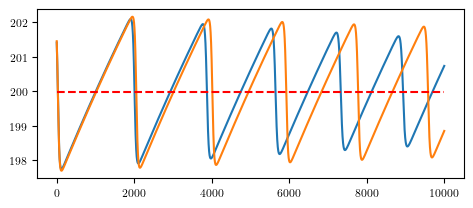

In [54]:
plt.plot(predicted["S_pred"])
plt.plot(data["S"])
plt.hlines(y=predicted["S_resting"], xmin=0, xmax=n_steps, color='r', linestyle='--')

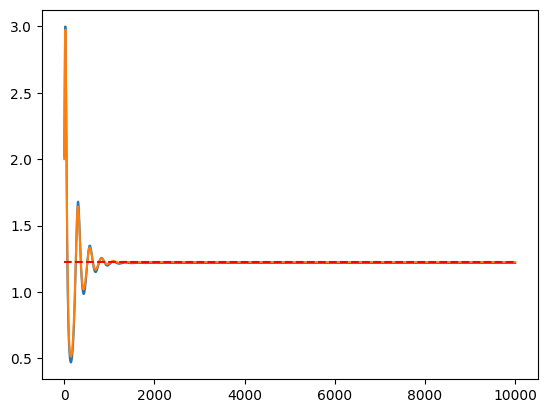

In [27]:
plt.plot((np.abs(np.vecdot(data["u"], (data["xyz"]), axis=1))))
plt.plot(np.abs(predicted["x_pred"]))
plt.hlines(y=predicted["X_resting"], xmin=0, xmax=n_steps, color='r', linestyle='--')

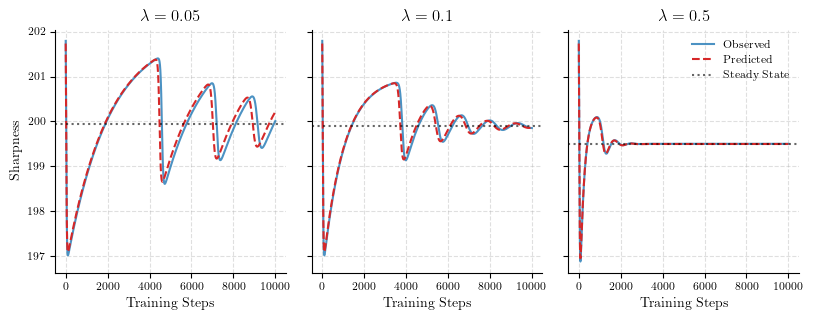

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Global NeurIPS Formatting Parameters
plt.rcParams.update({
    # Use LaTeX for text rendering (requires a local LaTeX installation)
    # If this throws an error, set to False and rely on the font.family fallback
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "Times"],
    "font.size": 10,           # Matches standard NeurIPS text
    "axes.labelsize": 10,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "figure.figsize": (8.25, 3.3), # 5.5 inch width fits perfectly in NeurIPS
    "lines.linewidth": 1.5,
    "axes.linewidth": 0.8,
})

# 2. Generate Synthetic Data (e.g., parameter decay dynamics)

x0=2.0
y0=1
z0=0
lr=0.01
alpha=0.1
beta=3
n_steps=10000
lambdas = [0.05, 0.1, 0.5]

# 3. Create 1x3 Subplots
fig, axes = plt.subplots(1, 3, sharey=True)

# Colors: using a colorblind-friendly approach
color_obs = '#1f77b4'  # Muted Blue
color_pred = '#d62728' # Brick Red
color_steady = 'black'

for i, (ax, lam) in enumerate(zip(axes, lambdas)):
    # Mathematical model: exponential decay to c
    data = toy_models.gd_run(
        x0=x0,
        y0=y0,
        z0=z0,
        lr=0.01,
        wd=lam,
        alpha=alpha,
        beta=beta,
        n_steps=n_steps,
    )
    
    predicted = toy_models.predict_dynamics(
        x0=x0,
        y0=y0,
        lr=lr,
        wd=lam,
        alpha=alpha,
        beta=beta,
        n_steps=n_steps,
    )

    # Plotting
    ax.plot(np.arange(n_steps+1), data["S"], linestyle='-', color=color_obs, alpha=0.8, label='Observed')
    ax.plot(np.arange(n_steps+1), predicted["S_pred"], linestyle='--', color=color_pred, label='Predicted')
    ax.axhline(200-lam, linestyle=':', color=color_steady, alpha=0.6, label='Steady State')

    # Formatting each axis
    ax.set_title(rf'$\lambda = {lam}$')
    ax.set_xlabel('Training Steps')
    
    # Only add y-label to the leftmost plot to save space
    if i == 0:
        ax.set_ylabel('Sharpness')
    if i == 2:
        ax.legend(loc='upper right', frameon=False) 
        
    # Clean up grid and spines
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# 4. Export safely with tight bounding box
plt.tight_layout()
plt.savefig('model_accuracy.pdf', format='pdf', bbox_inches='tight')
plt.show()

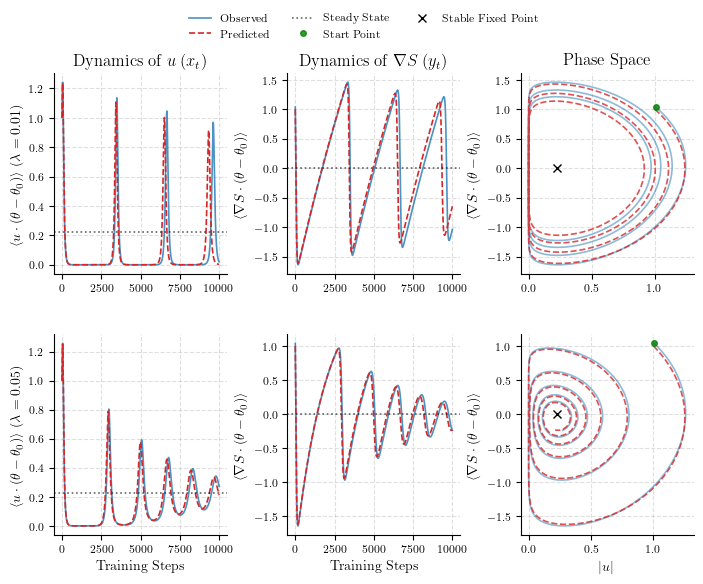

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Global NeurIPS Formatting Parameters
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "Times"],
    "font.size": 10,           
    "axes.labelsize": 10,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "figure.figsize": (8.25, 6), # 5.5 width for NeurIPS, 4.0 height for 2 rows
    "lines.linewidth": 1.2,       # Slightly thinner lines for denser subplots
    "axes.linewidth": 0.8,
})
x0=1
y0=0.5
z0=0
lr=0.01
alpha=0.1
beta=4
n_steps=10000
lambdas = [0.01, 0.05]

# Create 2x3 Subplots
fig, axes = plt.subplots(2, 3)
fig.subplots_adjust(wspace=0.35, hspace=0.3) # Give columns room to breathe

# Color scheme
color_obs = '#1f77b4'  
color_pred = '#d62728' 
color_steady = 'black'

for row, lam in enumerate(lambdas):
    # --- FETCH DATA ---
    # Replace these function calls with your actual toy_models calls
    data = toy_models.gd_run(
        x0=x0, y0=y0, z0=z0, lr=0.01, wd=lam, 
        alpha=alpha, beta=beta, n_steps=n_steps
    )
    predicted = toy_models.predict_dynamics(
        x0=x0, y0=y0, lr=0.01, wd=lam, 
        alpha=alpha, beta=beta, n_steps=n_steps
    )

    # --- PROCESS VARIABLES ---
    time_steps = np.arange(n_steps + 1)
    
    # Column 1 Data (u)
    u_obs = np.abs(np.vecdot(data["u"], data["xyz"], axis=1))
    u_pred = np.abs(predicted["x_pred"])
    u_steady = predicted["X_resting"]
    
    # Column 2 Data (\nabla S)
    grad_s_obs = np.vecdot(data["grad_S"], data["xyz"], axis=1)
    grad_s_pred = predicted["S_pred"] - 2/lr
    grad_s_steady = 0

    # --- PLOTTING ---
    
    # Col 1: u evolution
    ax_u = axes[row, 0]
    ax_u.plot(time_steps, u_obs, '-', color=color_obs, alpha=0.8, label='Observed')
    ax_u.plot(time_steps, u_pred, '--', color=color_pred, label='Predicted')
    ax_u.axhline(u_steady, color=color_steady, linestyle=':', alpha=0.6, label='Steady State')
    
    # Col 2: \nabla S evolution
    ax_s = axes[row, 1]
    ax_s.plot(time_steps, grad_s_obs, '-', color=color_obs, alpha=0.8)
    ax_s.plot(time_steps, grad_s_pred, '--', color=color_pred)
    ax_s.axhline(grad_s_steady, color=color_steady, linestyle=':', alpha=0.6)

    # Col 3: Phase Space (u vs \nabla S)
    ax_p = axes[row, 2]
    # Trajectories
    ax_p.plot(u_obs, grad_s_obs, '-', color=color_obs, alpha=0.5)
    ax_p.plot(u_pred, grad_s_pred, '--', color=color_pred, alpha=0.8)
    
    # Markers for Phase Space (Start and End)
    ax_p.plot(u_obs[0], grad_s_obs[0], 'go', markersize=4, label='Start Point', alpha=0.8)
    ax_p.plot(u_steady, grad_s_steady, 'kx', markersize=6, label='Stable Fixed Point')

    # --- FORMATTING & CLEANUP ---
    
    # Add Y-labels only to the left-most columns
    ax_u.set_ylabel(rf'$\langle u \cdot (\theta-\theta_0)\rangle$ ($\lambda={lam}$)')
    ax_s.set_ylabel(rf'$\langle \nabla S \cdot (\theta-\theta_0)\rangle$')
    ax_p.set_ylabel(rf'$\langle \nabla S \cdot (\theta-\theta_0)\rangle$')

    # Add titles only to the top row
    if row == 0:
        ax_u.set_title(r'Dynamics of $u\;(x_t)$')
        ax_s.set_title(r'Dynamics of $\nabla S\;(y_t)$')
        ax_p.set_title(r'Phase Space')
        
    # Add X-labels only to the bottom row
    if row == len(lambdas) - 1:
        ax_u.set_xlabel('Training Steps')
        ax_s.set_xlabel('Training Steps')
        ax_p.set_xlabel(rf'$\langle u \cdot (\theta-\theta_0)\rangle$')
        # ax_p.set_ylabel(r'$|\nabla S|$', labelpad=0) # labelpad prevents overlap

    # Grid and spines for all axes
    for ax in [ax_u, ax_s, ax_p]:
        ax.grid(True, linestyle='--', alpha=0.4)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

# 4. Legend Handling
# Place a single shared legend at the top of the entire figure to save space
# 4. Legend Handling
# Grab handles from the first column (time series lines)
handles_time, labels_time = axes[0, 0].get_legend_handles_labels()

# Grab handles from the third column (phase space markers)
handles_phase, labels_phase = axes[0, 2].get_legend_handles_labels()

# Combine the handles and labels
handles = handles_time + handles_phase
labels = labels_time + labels_phase

# Place the unified legend at the top. 
# Because we now have 5 items, ncol=3 will create two rows. 
# We bump bbox_to_anchor up slightly to (0.5, 1.08) to give those two rows enough room.
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 0.92), ncol=3, frameon=False)
# Lowered legend placement
# fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.98), ncol=3, frameon=False)
# 5. Export
plt.savefig('model_accuracy_2x3.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [1]:
import linear_network
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
# Sharpness trajectories: larger γ grows more slowly toward the cap (same seed per arch as elsewhere).
import os

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "Times"],
    "font.size": 12,
    "axes.labelsize": 10,
    "legend.fontsize": 12,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "figure.figsize": (5.5, 2),
    "lines.linewidth": 1.5,
    "axes.linewidth": 0.8,
})

RESULTS_DIR = os.environ.get("RESULTS", "slt-results")
DATASET = "cifar10-5k"
LOSS = "mse"

MLP_ARCH = "full_200"
MLP_LR = 0.02
MLP_SEED = 10
MLP_GAMMAS = [0, 0.01, 0.015, 0.02]

CNN_ARCH = "cnn-relu"
CNN_LR = 0.01
CNN_SEED = "10_true"
CNN_GAMMAS = [0, 0.01, 0.015, 0.02]

SHARPNESS_CAP = 80

cmap = cm.get_cmap("RdBu")
mlp_colors = [cmap(t) for t in np.linspace(0.95, 0.05, len(MLP_GAMMAS))]
cnn_colors = [cmap(t) for t in np.linspace(0.95, 0.05, len(CNN_GAMMAS))]


def sharpness_vec(gd_s):
    if gd_s.dim() > 1:
        s = gd_s[:, 0]
    else:
        s = gd_s
    if hasattr(s, "detach"):
        return s.detach().cpu().numpy()
    return np.asarray(s)


def step_freq(wd):
    if wd in [0.01, 1e-5, 1e-4, 1e-3, 0.001, 0.03]:
        return 50
    return 25


fig, (ax_mlp, ax_cnn) = plt.subplots(1, 2, sharey=True)

thr_mlp = 2.0 / MLP_LR
ax_mlp.axhline(y=thr_mlp, color="black", linestyle="--", alpha=0.6)
for gamma, color in zip(MLP_GAMMAS, mlp_colors):
    gd_path = f"{RESULTS_DIR}/{DATASET}/{MLP_ARCH}/seed_{MLP_SEED}/{LOSS}/gd/lr_{MLP_LR}/wd_{gamma}/eigs_final.pt"
    gd_s = torch.load(gd_path)
    sharp = sharpness_vec(gd_s)
    freq = step_freq(gamma)
    steps = np.arange(len(sharp)) * freq
    ax_mlp.plot(steps, sharp, color=color, alpha=0.85, label=rf"$\gamma={gamma}$")

ax_mlp.set_xlabel("Training Step")
ax_mlp.set_ylabel("Sharpness")
ax_mlp.set_ylim(0, SHARPNESS_CAP)
ax_mlp.set_xlim(0, 10000)
ax_mlp.set_title(fr"MLP ReLU (seed {MLP_SEED})")
ax_mlp.grid(True, linestyle="--", alpha=0.4)
ax_mlp.spines["top"].set_visible(False)
ax_mlp.spines["right"].set_visible(False)

thr_cnn = 2.0 / CNN_LR
ax_cnn.axhline(y=thr_cnn, color="black", linestyle="--", alpha=0.6)
for gamma, color in zip(CNN_GAMMAS, cnn_colors):
    gd_path = f"{RESULTS_DIR}/{DATASET}/{CNN_ARCH}/seed_{CNN_SEED}/{LOSS}/gd/lr_{CNN_LR}/wd_{gamma}/eigs_final.pt"
    gd_s = torch.load(gd_path)
    sharp = sharpness_vec(gd_s)
    freq = step_freq(gamma)
    steps = np.arange(len(sharp)) * freq
    ax_cnn.plot(steps, sharp, color=color, alpha=0.85, label=rf"$\gamma={gamma}$")

ax_cnn.set_xlabel("Training Step")
ax_cnn.set_ylim(0, SHARPNESS_CAP)
ax_cnn.set_xlim(0, 10000)
ax_cnn.set_title(fr"CNN ReLU (seed {CNN_SEED})")
ax_cnn.grid(True, linestyle="--", alpha=0.4)
ax_cnn.spines["top"].set_visible(False)
ax_cnn.spines["right"].set_visible(False)

handles, labels = ax_mlp.get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, 1.0),
    ncol=4,
    frameon=False,
    fontsize=11,
)
plt.subplots_adjust(top=0.82, wspace=0.28)
plt.savefig("sharpness_gamma_slowdown_rdbu.pdf", format="pdf", bbox_inches="tight")
plt.show()


In [14]:
# Deep linear synthetic MSE: L, grad L, theta, S, u, grad S (same spirit as toy_models.gd_run)
n, d, depth = 1000, 10, 2
lr, wd = 0.05, 0.01
n_steps = 200
lin = linear_network.gd_run(
    n, d, depth, lr=lr, wd=wd, n_steps=n_steps, seed=0, label_noise_std=0.0
)


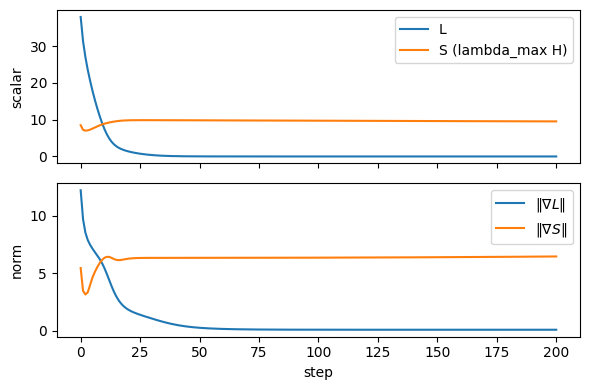

In [15]:
fig, ax = plt.subplots(2, 1, figsize=(6, 4), sharex=True)
ax[0].plot(lin["L"], label="L")
ax[0].plot(lin["S"], label="S (lambda_max H)")
ax[0].legend()
ax[0].set_ylabel("scalar")
ax[1].plot(np.linalg.norm(lin["grad_L"], axis=1), label=r"$\|\nabla L\|$")
ax[1].plot(np.linalg.norm(lin["grad_S"], axis=1), label=r"$\|\nabla S\|$")
ax[1].legend()
ax[1].set_xlabel("step")
ax[1].set_ylabel("norm")
fig.tight_layout()
